## 1. Import dataset

In [1]:
import os
import sys

sys.path.append(os.path.abspath(".."))   # Add root path to sys.path
os.chdir("..")  # Change working directory to root path

In [2]:
import pandas as pd

data_path = "data/original/covariant_imputed_continuous.csv"
original_df = pd.read_csv(data_path)

original_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11671 entries, 0 to 11670
Data columns (total 31 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   iso_code                        11671 non-null  object 
 1   continent                       11671 non-null  object 
 2   location                        11671 non-null  object 
 3   date                            11671 non-null  object 
 4   new_cases_smoothed_per_million  11671 non-null  float64
 5   people_vaccinated_per_hundred   11671 non-null  float64
 6   stringency_index                11671 non-null  float64
 7   population                      11671 non-null  float64
 8   median_age                      11671 non-null  float64
 9   total_tests_per_thousand        11671 non-null  float64
 10  classification                  11671 non-null  object 
 11  Overall_score                   11671 non-null  float64
 12  group                           

## 2. Process columns

In [3]:
# Country-identifier columns
index_columns = ['iso_code', 'location']

# OWID columns
time_varying_columns = ['total_tests_per_thousand', 'people_vaccinated_per_hundred', 'stringency_index']
time_fixed_columns = ['population', 'median_age', 'Overall_score', 'date']
categorical_columns = ['continent', 'classification', 'group']

# Covariant columns (variants and recombinant)
original_covariant_columns = [
                        '20A', '20B', '20C', '20E', 'recombinant',
                        'Beta', 'Alpha', 'Delta', 'Epsilon', 'Eta',
                        'Iota', 'Lambda', 'Mu', 'Omicron', 'S:677',
                        'Gamma', 'Kappa'
                    ]
constraint_columns = ['total_sequence']

total_columns = index_columns + time_varying_columns + time_fixed_columns + categorical_columns + original_covariant_columns + constraint_columns

for col in total_columns:
    if col not in original_df.columns:
        print(f"Column '{col}' is missing from the DataFrame.")

for col in original_df.columns:
    if col not in total_columns:
        print(f"Column '{col}' is unexpected and not categorized.")

len(total_columns)

Column 'new_cases_smoothed_per_million' is unexpected and not categorized.


30

### 2.1 Preprocess data to numeric types

In [4]:
processed_df = original_df.copy()

# process date column
processed_df['date'] = pd.to_datetime(processed_df['date'], format='%Y-%m-%d')
first_date = processed_df['date'].min()
processed_df['date'] = (processed_df['date'] - first_date).dt.days

# process categorical columns => one-hot encoding
categiorical_columns = [c for c in processed_df.columns if processed_df[c].dtype == 'object' and c not in index_columns]
encoded_categorial_columns = []

for c in categiorical_columns:
    dummies = pd.get_dummies(processed_df[c], prefix=c)

    # drop the first dummy column to avoid multicollinearity
    dummies.drop(columns=dummies.columns[0], inplace=True)
    encoded_categorial_columns.extend(dummies.columns)
    
    dummies = dummies.astype(int)
    processed_df = pd.concat([processed_df, dummies], axis=1)
    processed_df.drop(columns=[c], inplace=True)

# process covariant columns => add prefix "covariant_"
for c in original_covariant_columns:
    processed_df.rename(columns={c: f"covid_{c}"}, inplace=True)

covariant_columns = [f"covid_{c}" for c in original_covariant_columns]

processed_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11671 entries, 0 to 11670
Data columns (total 39 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   iso_code                            11671 non-null  object 
 1   location                            11671 non-null  object 
 2   date                                11671 non-null  int64  
 3   new_cases_smoothed_per_million      11671 non-null  float64
 4   people_vaccinated_per_hundred       11671 non-null  float64
 5   stringency_index                    11671 non-null  float64
 6   population                          11671 non-null  float64
 7   median_age                          11671 non-null  float64
 8   total_tests_per_thousand            11671 non-null  float64
 9   Overall_score                       11671 non-null  float64
 10  covid_recombinant                   9713 non-null   float64
 11  covid_20A                           7661 

### 2.3 Check imputable status

**Idea**: Within a row, if sum of the every non-missing covariant equals total_sequence, then the missing value is surely zero.

$\rightarrow$ Directly impute zero for these cases, and remove them from the missing list.

In [5]:
from tqdm import tqdm

count = 0

for index, row in tqdm(processed_df.iterrows(), total=processed_df.shape[0], desc="Checking imputable status"):
    non_missing_sum = row[covariant_columns].sum()
    total_sequence = row['total_sequence']

    if non_missing_sum == total_sequence:
        count += 1
        for covariant in covariant_columns:
            if pd.isna(row[covariant]):
                processed_df.at[index, covariant] = 0

print(f"Number of filled rows: {count}")
processed_df.info()

Checking imputable status: 100%|██████████| 11671/11671 [00:02<00:00, 4314.24it/s]

Number of filled rows: 5678
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11671 entries, 0 to 11670
Data columns (total 39 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   iso_code                            11671 non-null  object 
 1   location                            11671 non-null  object 
 2   date                                11671 non-null  int64  
 3   new_cases_smoothed_per_million      11671 non-null  float64
 4   people_vaccinated_per_hundred       11671 non-null  float64
 5   stringency_index                    11671 non-null  float64
 6   population                          11671 non-null  float64
 7   median_age                          11671 non-null  float64
 8   total_tests_per_thousand            11671 non-null  float64
 9   Overall_score                       11671 non-null  float64
 10  covid_recombinant                   11011 non-null  float64
 11  covid_20A    

### 2.2 Find missing columns and its missing part

In [6]:
from dataclasses import dataclass

@dataclass
class MissingColumn:
    name: str
    missing_indices: pd.Index

missing_columns = [MissingColumn(name=c, missing_indices=processed_df[processed_df[c].isnull()].index) for c in processed_df.columns if processed_df[c].isnull().any()]
missing_columns[0].missing_indices[:10]

Index([0, 1, 2, 3, 4, 5, 6, 7, 8, 9], dtype='int64')

## 3. Define classes for imputation process

### 3.1 VariableModel classes

In [23]:
import pandas as pd
import numpy as np

from src.variables import Parameter, VariableModel
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.inspection import permutation_importance
from scipy.stats import truncnorm

class HurdleRFVariableModel(VariableModel):
    name: str
    missing_indices: pd.Index
    zi_predictors: list[str]
    rf_predictors: list[str]
    zi_model: RandomForestClassifier
    rf_model: RandomForestRegressor
    residual_std: float    # store residuals for later use in sampling

    def __init__(self, name: str, missing_indices: pd.Index, zi_predictors: list[str], rf_predictors: list[str]):
        self.name = name
        self.missing_indices = missing_indices
        self.zi_predictors = zi_predictors
        self.rf_predictors = rf_predictors
    
    def _fit_distribution(
            self, X_train_zi: pd.DataFrame, X_train_rf: pd.DataFrame, y_train: pd.Series,
        ) -> list[Parameter]:
        """
        Fit the hurdle model to the training data. Return the fitted parameters with its values.
        """
        # --- Stage 1: Zero-Inflated ---
        # Label: 1 if zero, 0 if non-zero
        y_binary = (y_train == 0).astype(int)

        # Use Random Forest Classifier to predict the probability of zero vs non-zero
        clf = RandomForestClassifier(n_estimators=50, max_depth=10, n_jobs=-1, random_state=42)
        clf.fit(X_train_zi, y_binary)

        # --- Stage 2: Count Model ---
        # Filter out zero values for the count model
        non_zero_indices = y_train[y_train > 0].index
        X_train_rf_non_zero = X_train_rf.loc[non_zero_indices]
        y_train_non_zero = y_train.loc[non_zero_indices]

        # Use Random Forest Regressor to predict the count values for non-zero data
        reg = RandomForestRegressor(n_estimators=50, max_depth=10, n_jobs=-1, random_state=42)
        reg.fit(X_train_rf_non_zero, y_train_non_zero)

        # Store the fitted models for later use in sampling
        self.zi_model = clf
        self.rf_model = reg

        ## Compute feature importance for both models
        perm_zi = permutation_importance(
            clf, X_train_zi, y_binary,
            n_repeats=5,
            random_state=42,
        )

        perm_rf = permutation_importance(
            reg, X_train_rf_non_zero, y_train_non_zero,
            n_repeats=5,
            random_state=42,
        )

        parameters: list[Parameter] = []
        for i, predictor in enumerate(self.zi_predictors):
            parameters.append(
                Parameter(name=predictor, value=perm_zi.importances_mean[i], component="zi")
            )

        for i, predictor in enumerate(self.rf_predictors):
            parameters.append(Parameter(name=predictor, value=perm_rf.importances_mean[i], component="rf"))

        return parameters
    
    def fit(self, imputed_data: pd.DataFrame) -> list[Parameter]:
        """
        Fit the hurdle model to the training data. Return the fitted parameters with its values.
        """
        columns = list(set([self.name] + self.zi_predictors + self.rf_predictors))
        data = imputed_data[columns].copy()
        train_data = data.drop(index=self.missing_indices)

        X_train_zi = train_data[self.zi_predictors]
        X_train_rf = train_data[self.rf_predictors]

        y_train = train_data[self.name]

        parameters = self._fit_distribution(X_train_zi, X_train_rf, y_train)
        self.residual_std = np.std(y_train - self.rf_model.predict(X_train_rf))

        return parameters

    def sample(self, imputed_data: pd.DataFrame) -> list:
        """
        Vectorized sampling for all missing rows.
        Returns an array aligned with self.missing_indices.
        """

        # --- Extract rows ---
        rows = imputed_data.loc[self.missing_indices]

        X_zi = rows[self.zi_predictors]
        X_rf = rows[self.rf_predictors]

        # --- Model predictions (vectorized) ---
        prob_zero = self.zi_model.predict_proba(X_zi)[:, 1]   # shape (n,)
        mu = self.rf_model.predict(X_rf)                      # shape (n,)

        sigma = self.residual_std

        # --- Constraint ---
        total_seq = rows["total_sequence"].values

        covariate_columns = [c for c in imputed_data.columns if c.startswith("covid_")]
        covariates = imputed_data[covariate_columns].values
        current_var = imputed_data[self.name].values

        sum_others = covariates.sum(axis=1) - current_var
        sum_others = sum_others[self.missing_indices]

        max_allowed = total_seq - sum_others
        max_allowed = np.maximum(max_allowed, 0.0)

        # --- Zero model ---
        is_zero = np.random.binomial(1, prob_zero)

        # --- Initialize output ---
        values = np.zeros_like(mu)

        # --- Mask for valid truncated sampling ---
        valid_mask = (max_allowed > 0) & (is_zero == 0)

        if np.any(valid_mask):
            mu_v = mu[valid_mask]
            max_v = max_allowed[valid_mask]

            if sigma < 1e-6:
                values[valid_mask] = np.clip(mu_v, 0.0, max_v)
            else:
                a = (0.0 - mu_v) / sigma
                b = (max_v - mu_v) / sigma

                values[valid_mask] = truncnorm.rvs(a, b, loc=mu_v, scale=sigma)

        # --- Zero cases already 0 ---
        return values.tolist()

    def __str__(self) -> str:
        def _format_list(lst, max_items=5):
            if len(lst) <= max_items:
                return ", ".join(lst)
            return ", ".join(lst[:max_items]) + f", ... (+{len(lst) - max_items})"
        
        return (
            f"HurdleRFVariableModel(\n"
            f"  name={self.name},\n"
            f"  n_missing={len(self.missing_indices)},\n"
            f"  zi_predictors=[{_format_list(self.zi_predictors)}],\n"
            f"  rf_predictors=[{_format_list(self.rf_predictors)}]\n"
            f")"
        )

In [18]:
from dataclasses import dataclass, Field
from typing import List, Any
from time import time

@dataclass
class VariableRecord:
    name: str
    params: List[Parameter]
    imputed_values: List[float]
    fitting_time: float = 0.0

@dataclass
class VariableHistory:
    name: str
    history: List[VariableRecord]
    iterations: List[int]


class ParameterConvergenceChecker:
    convergence_threshold: float

    def __init__(self, convergence_threshold: float = 1e-4):
        self.convergence_threshold = convergence_threshold

    def _params_to_dict(self, params: List[Parameter]) -> dict[tuple, float]:
        """
        Convert parameter list into a dict keyed by (name, component)
        """
        return {(p.name, p.component): p.value for p in params}

    def _compute_param_change(self, prev: dict[tuple, float], curr: dict[tuple, float], eps: float = 1e-6) -> float:
        """
        Compute robust relative change between two parameter dictionaries.
        Returns a scalar summary (median relative change).
        """
        changes = []

        for key in curr:
            if key in prev:
                prev_val = prev[key]
                curr_val = curr[key]

                denom = abs(prev_val) + eps
                rel_change = abs(curr_val - prev_val) / denom
                changes.append(rel_change)

        if not changes:
            return np.inf

        return float(np.median(changes))

    def _check_variable_convergence(self, var_history: VariableHistory) -> bool:
        """
        Check convergence for a single variable.
        """
        if len(var_history.history) < 2:
            return False

        prev = self._params_to_dict(var_history.history[-2].params)
        curr = self._params_to_dict(var_history.history[-1].params)

        change = self._compute_param_change(prev, curr)

        return change < self.convergence_threshold

    def _check_param_convergence(self, variables: dict[str, VariableHistory]) -> bool:
        """
        check the convergence of the parameters of the fitted models.
        """
        for var_history in variables.values():
            if not self._check_variable_convergence(var_history):
                print(f"Variable '{var_history.name}' has not converged yet.")
                return False
        return True

class Tracker:
    variables: dict[str, VariableHistory]
    convergence_threshold: float = 1e-4
    convergence_checker: ParameterConvergenceChecker

    def __init__(self, missing_variables: List[str], convergence_threshold: float = 1e-4):
        self.variables = {
            var_name: VariableHistory(name=var_name, history=[], iterations=[]) for var_name in missing_variables
        }
        self.convergence_threshold = convergence_threshold
        self.convergence_checker = ParameterConvergenceChecker(convergence_threshold=convergence_threshold)

    def record(self, iteration: int, variable_record: VariableRecord):
        var_name = variable_record.name
        self.variables[var_name].history.append(variable_record)
        self.variables[var_name].iterations.append(iteration)

    def get_current_data(self) -> dict[str, list[float]]:
        """
        Return the current imputed dataset (after the latest iteration).
        """
        current_data = {}
        for var_name, var_history in self.variables.items():
            if var_history.history:
                current_data[var_name] = var_history.history[-1].imputed_values
            else:
                raise ValueError(f"No history found for variable '{var_name}'. Cannot get current data.")

        return current_data

    def check_early_stopping(self):
        return False
        return self.convergence_checker._check_param_convergence(self.variables)

    def print_iteration_summary(self, iteration: int):
        def _get_param_name(param: Parameter) -> str:
            param_name = str(param.name)
            param_type = param.component

            if param_name.startswith("covid_"):
                param_name = param_name[len("covid_"):]
            param_name = param_name[:5]     # shorten for display
            return f"{param_type}_{param_name}"
        
        variable_records = [var_history.history[iteration] for var_history in self.variables.values() if var_history.history]
        coefficients_matrix = {var_name: {_get_param_name(param): "" for param in var_history.history[0].params} for var_name, var_history in self.variables.items()}

        for var_record in variable_records:
            for param in var_record.params:
                param_name = _get_param_name(param)
                coefficients_matrix[var_record.name][param_name] = f"{param.value:.4f}"

        df = pd.DataFrame(coefficients_matrix).T
        display(df)

In [ ]:
from tqdm import tqdm
from time import time

MAX_ITERATIONS = 100
features = covariant_columns + time_varying_columns + time_fixed_columns + encoded_categorial_columns

def check_total_sequence_constraints(full_df: pd.DataFrame) -> bool:
    """
    Check if the total sequence constraints are satisfied.
    """
    # Implementation for checking total sequence constraints
    print(f"Number of rows violating total sequence constraints: {(full_df[covariant_columns].sum(axis=1) > full_df['total_sequence']).sum()}")
    return (full_df[covariant_columns].sum(axis=1) <= full_df['total_sequence']).all()

class FCSEngine:
    variables: list[HurdleRFVariableModel]
    original_df: pd.DataFrame
    tracker: Tracker

    def __init__(self, variables: list[HurdleRFVariableModel], original_df: pd.DataFrame, tracker: Tracker, max_iterations: int = MAX_ITERATIONS):
        self.variables = variables
        self.original_df = original_df
        self.tracker = tracker
        self.max_iterations = max_iterations
    
    def _initialize_imputation(self):
        # Initialize imputation for the variable (e.g., using mean or median)
        df0 = self.original_df.copy()

        for variable in self.variables:
            # fill missing values with mean of the variable
            df0.loc[variable.missing_indices, variable.name] = 0
            self.tracker.record(0, VariableRecord(
                name=variable.name,
                params=[],  # no parameters for initialization
                imputed_values=df0[variable.name].iloc[variable.missing_indices].tolist()
            ))
    
    def get_current_data(self) -> pd.DataFrame:
        """
        Return the current imputed dataset (after the latest iteration).
        """
        current_data_dict = self.tracker.get_current_data() # get the latest imputed values into the tracker
        imputed_df = self.original_df.copy()

        for var_name, imputed_values in current_data_dict.items():
            current_var = self.variables[self.variables.index(next(v for v in self.variables if v.name == var_name))]
            imputed_df.loc[current_var.missing_indices, var_name] = imputed_values

        return imputed_df
    
    def get_full_data(self, iteration: int) -> pd.DataFrame:
        """
        Return the imputed dataset for the given iteration.
        """
        # get non-missing data from the original dataset
        imputed_df = self.original_df.copy()

        for missing_var in self.variables:
            var_name = missing_var.name
            missing_indices = missing_var.missing_indices

            if iteration >= len(self.tracker.variables[var_name].history):
                raise ValueError(f"No imputation record found for variable '{var_name}' at iteration {iteration}")
            
            imputed_values = self.tracker.variables[var_name].history[iteration].imputed_values
            imputed_df.loc[missing_indices, var_name] = imputed_values

        return imputed_df

    def _print_header(self):
        print("\n" + "="*88)
        print(f"| HURDLE RF IMPUTATION PIPELINE".ljust(87) + "|")
        print(f"| Max Iterations: {self.max_iterations:<4}".ljust(87) + "|")
        print("="*88 + "\n")
    
    def _print_separator(self, width: int = 88):
        print("+" + "-" * (width - 2) + "+")
    
    def _print_iteration_header(self, iteration: int):
        print(f"ITERATION {iteration}/{self.max_iterations-1}".center(88, " "))

    def _print_iteration_summary(self, iteration: int, variable_records: list[VariableRecord]):
        coefficients_matrix = {var_name: {param_name: "" for param_name in features} for var_name in [vr.name for vr in variable_records]}

        for var_record in variable_records:
            for param in var_record.params:
                coefficients_matrix[var_record.name][param.name] = f"{param.value:.2f}"
        
        display_df = pd.DataFrame(coefficients_matrix).T
        display(display_df)
        
        self._print_separator()

    def run(self):
        self._print_header()
        self._initialize_imputation()
        
        for iteration in range(1, self.max_iterations):
            self._print_iteration_header(iteration)

            pbar = tqdm(self.variables)
            
            ## Fit the model and sample for each variable
            for variable in pbar:
                # Implementation for running the FCS engine
                pbar.set_description(f"{variable.name} - retrieving data")
                last_imputed_data = self.get_current_data()     # get the current imputed dataset

                begin_time = time()
                pbar.set_description(f"{variable.name} - fitting")
                parameters = variable.fit(last_imputed_data)

                pbar.set_description(f"{variable.name} - sampling")
                imputed_values = variable.sample(last_imputed_data)

                self.tracker.record(iteration, VariableRecord(
                    name=variable.name,
                    params=parameters,
                    imputed_values=imputed_values,
                    fitting_time=time() - begin_time
                ))

            # self.tracker.record(iteration, new_entry)
            self.tracker.print_iteration_summary(iteration)

            print(f"Checking for convergence...")
            if self.tracker.check_early_stopping():
                print(f"Convergence reached at iteration {iteration}")
                break

## 4. Simulate imputation process

### 4.1 Create FCSEngine instance and run imputation process

In [ ]:
# processed_df = processed_df[index_columns + continuous_columns + encoded_categorial_columns + covariant_columns + ['total_sequence']]
hurdle_variables: list[HurdleRFVariableModel] = []

for covariant in covariant_columns:
    missing_indices = processed_df[processed_df[covariant].isnull()].index
    if len(missing_indices) == 0:
        continue
    zi_predictors = time_fixed_columns + time_varying_columns
    rf_predictors = [col for col in processed_df.columns if col != covariant and col not in index_columns and col not in ['total_sequence', 'new_cases_smoothed_per_million']]

    variable_model = HurdleRFVariableModel(
        name=covariant,
        missing_indices=missing_indices,
        zi_predictors=zi_predictors,
        rf_predictors=rf_predictors
    )
    hurdle_variables.append(variable_model)

fcs = FCSEngine(
    variables=hurdle_variables, 
    original_df=processed_df, 
    tracker=Tracker([v.name for v in hurdle_variables], convergence_threshold=1e-4)
)

# fcs._initialize_imputation()
fcs.run(max_iterations=20)

imputed_df = fcs.get_current_data()

imputed_df.info()


| HURDLE RF IMPUTATION PIPELINE                                                        |
| Max Iterations: 100                                                                  |

                                     ITERATION 1/99                                     


covid_S:677 - sampling: 100%|██████████| 14/14 [01:18<00:00,  5.57s/it]            


,zi_date,zi_peopl,zi_strin,zi_popul,zi_media,zi_total,zi_Overa,zi_recom,zi_20B,zi_20C,...,rf_Iota,rf_Lambd,rf_Mu,rf_Omicr,rf_S:677,rf_conti,rf_class,rf_group,zi_20A,rf_20A
covid_20A,0.0128,0.0063,0.0038,0.0027,0.0070,0.0038,0.0051,-0.0000,0.0013,0.0004,...,0.0001,0.0001,0.0000,0.0000,0.0026,-0.0000,-0.0000,0.0000,NaN,NaN
covid_20B,0.0066,0.0043,0.0021,0.0026,0.0019,0.0040,0.0051,0.0008,NaN,0.0010,...,0.3410,0.0012,0.0025,0.0000,0.0058,0.0000,0.0087,0.0064,0.0064,0.0101
covid_20C,0.0082,0.0056,0.0005,0.0029,0.0008,0.0027,0.0012,0.0000,0.0016,NaN,...,-0.0000,0.0002,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0064,0.2611
covid_20E,0.0147,0.0041,0.0029,0.0019,0.0027,0.0035,0.0041,0.0002,0.0017,0.0008,...,0.0001,0.0000,0.0000,-0.0000,-0.0000,0.0000,-0.0000,0.0000,0.0273,1.7755
covid_recombinant,0.0555,0.0145,0.0124,0.0111,0.0077,0.0105,0.0099,NaN,0.0003,0.0000,...,0.0001,0.0040,0.0129,0.8306,-0.0000,0.0012,0.0000,0.0000,-0.0000,0.0000
covid_Beta,0.0128,0.0083,0.0039,0.0072,0.0071,0.0068,0.0048,0.0004,0.0003,0.0001,...,0.0033,0.0253,0.0059,0.0000,0.0004,0.0000,0.0011,0.0001,0.0015,0.1705
covid_Alpha,0.0519,0.0090,0.0130,0.0041,0.0105,0.0055,0.0067,0.0005,0.0003,0.0000,...,0.1588,0.0039,0.0021,0.0000,0.0022,0.0000,0.0000,0.0000,0.0049,0.0092
covid_Epsilon,0.0042,0.0020,0.0006,0.0017,0.0009,0.0017,0.0015,0.0002,0.0053,0.0002,...,0.0207,0.0011,-0.0008,0.0000,1.2998,0.0000,0.0000,0.0000,0.0021,0.0001
covid_Eta,0.0086,0.0051,0.0021,0.0026,0.0064,0.0049,0.0043,-0.0000,0.0006,0.0001,...,0.0107,0.0026,0.0011,0.0000,0.0017,0.0000,0.0000,0.0011,0.0017,0.0756
covid_Iota,0.0015,0.0007,0.0006,0.0005,0.0007,0.0013,0.0003,0.0000,0.0013,0.0000,...,NaN,0.0066,0.0009,0.0000,0.0028,0.0000,0.0000,0.0000,0.0003,0.0011


Checking for convergence...
                                     ITERATION 2/99                                     


covid_S:677 - sampling: 100%|██████████| 14/14 [01:17<00:00,  5.53s/it]            


...

Checking for convergence...
                                    ITERATION 19/99                                     


covid_S:677 - sampling: 100%|██████████| 14/14 [01:19<00:00,  5.65s/it]            


,zi_date,zi_peopl,zi_strin,zi_popul,zi_media,zi_total,zi_Overa,zi_recom,zi_20B,zi_20C,...,rf_Iota,rf_Lambd,rf_Mu,rf_Omicr,rf_S:677,rf_conti,rf_class,rf_group,zi_20A,rf_20A
covid_20A,0.0095,0.0072,0.0022,0.0018,0.0067,0.0032,0.0041,0.0000,0.0012,0.0012,...,0.0001,0.0002,0.0000,0.0000,0.0075,0.0000,0.0000,0.0000,NaN,NaN
covid_20B,0.0078,0.0057,0.0027,0.0025,0.0015,0.0032,0.0045,0.0006,NaN,0.0015,...,0.3798,0.0011,0.0010,0.0000,0.0045,0.0000,0.0062,0.0068,0.0076,0.0075
covid_20C,0.0068,0.0077,0.0012,0.0039,0.0012,0.0027,0.0015,0.0000,0.0012,NaN,...,0.0002,-0.0000,0.0000,0.0000,0.0001,0.0000,0.0000,0.0000,0.0057,0.2601
covid_20E,0.0139,0.0029,0.0019,0.0016,0.0024,0.0020,0.0035,0.0000,0.0019,0.0005,...,0.0001,0.0000,0.0000,-0.0000,0.0001,0.0000,0.0000,-0.0000,0.0263,1.9200
covid_recombinant,0.0603,0.0142,0.0106,0.0091,0.0098,0.0137,0.0123,NaN,0.0005,0.0000,...,0.0000,0.0034,0.0145,0.8175,0.0000,0.0014,0.0000,0.0000,-0.0001,0.0000
covid_Beta,0.0120,0.0067,0.0033,0.0082,0.0078,0.0052,0.0044,0.0006,0.0004,0.0003,...,0.0990,0.0214,0.0107,0.0000,0.0183,-0.0000,0.0007,0.0002,0.0023,0.0775
covid_Alpha,0.0431,0.0082,0.0092,0.0035,0.0074,0.0061,0.0053,-0.0002,0.0002,0.0002,...,0.1572,0.0033,0.0005,0.0000,0.0026,0.0000,0.0000,0.0007,0.0036,0.0097
covid_Epsilon,0.0048,0.0027,0.0013,0.0027,0.0008,0.0012,0.0020,0.0004,0.0064,0.0002,...,0.0184,0.0010,-0.0003,0.0000,1.3481,0.0000,0.0000,0.0000,0.0014,0.0007
covid_Eta,0.0085,0.0047,0.0022,0.0038,0.0057,0.0063,0.0033,0.0003,0.0004,0.0000,...,0.0203,0.0017,0.0014,0.0000,0.0012,0.0000,0.0000,0.0008,0.0019,0.0656
covid_Iota,0.0017,0.0010,0.0012,0.0004,0.0006,0.0013,0.0006,0.0000,0.0011,0.0000,...,NaN,0.0090,0.0059,0.0000,0.0045,0.0000,-0.0000,0.0000,0.0007,0.0014


Checking for convergence...


TypeError: '>=' not supported between instances of 'dict' and 'int'

## 5. Illustration of imputation process

### 5.1 Plot estimated coefficients of each variable across iterations

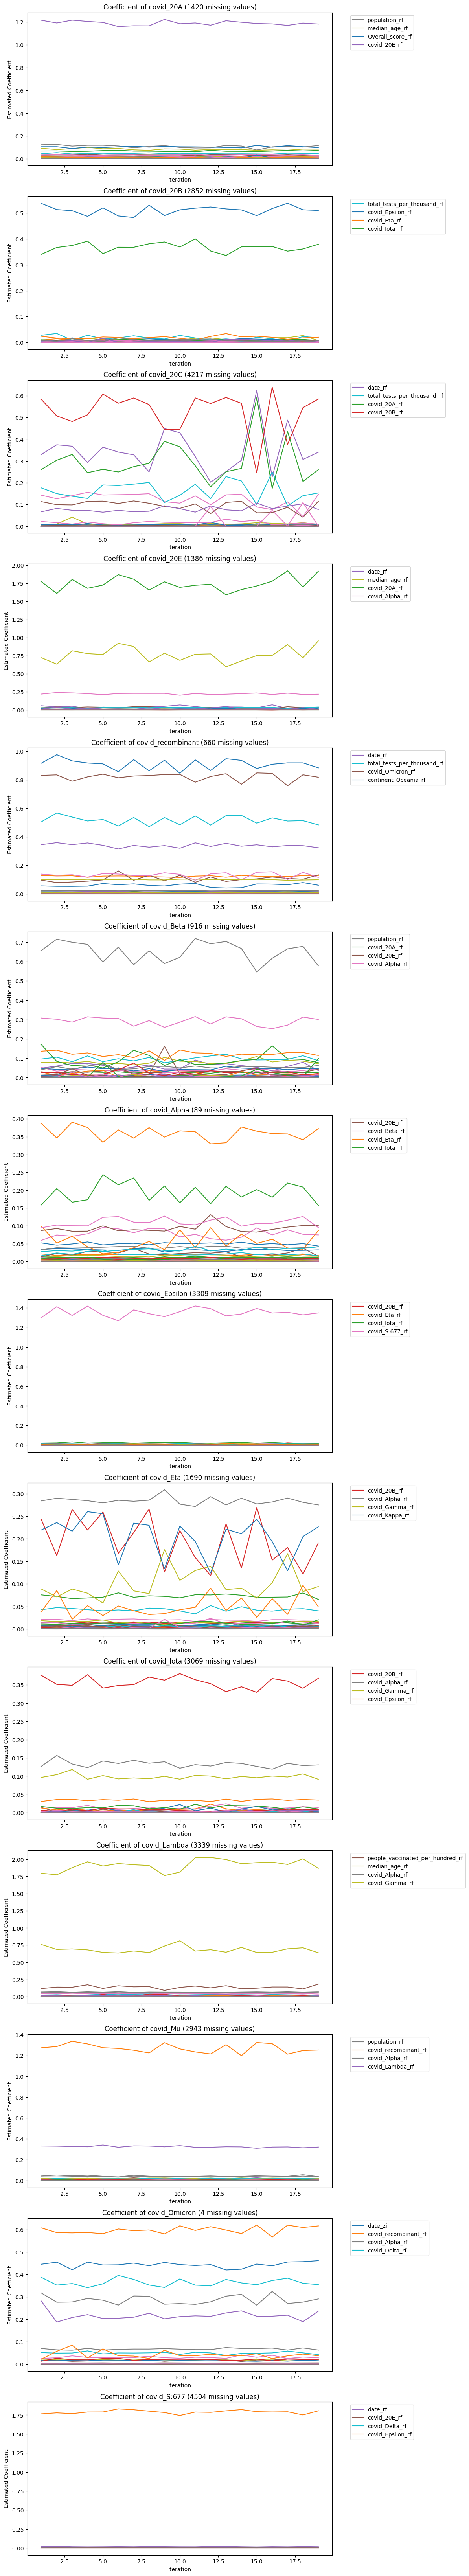

In [28]:
import matplotlib.pyplot as plt

missing_covariant_columns = [c for c in covariant_columns if c in fcs.tracker.variables]

plt.figure(figsize=(10, 6 * len(missing_covariant_columns)))
for idx, covariant_col in enumerate(missing_covariant_columns):
    plt.subplot(len(missing_covariant_columns), 1, idx + 1)

    coefficients_over_iterations = {}

    var_history = fcs.tracker.variables[covariant_col].history

    for record in var_history:
        for param in record.params:
            par_name = param.name
            par_value = param.value
            par_type = param.component
            type_key = f"{par_name}_{par_type}"

            if type_key not in coefficients_over_iterations:
                coefficients_over_iterations[type_key] = []
            coefficients_over_iterations[type_key].append(par_value)
    
    sorted_by_max = sorted(
        coefficients_over_iterations.items(), 
        key=lambda item: max(item[1]), 
        reverse=True
    )

    top_values = [item[0] for item in sorted_by_max[:4]]

    # coefficients_over_iterations
    iterations = range(1, len(var_history))
    for predictor, values in coefficients_over_iterations.items():
        # max value = max(values)
        if predictor in top_values:
            plt.plot(iterations, values, label=f"{predictor}")
        else:
            plt.plot(iterations, values)

    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

    plt.xlabel('Iteration')
    plt.ylabel('Estimated Coefficient')
    plt.title(f'Coefficient of {covariant_col} ({len(var_history[0].imputed_values)} missing values)')
plt.show()

### 5.2 Plot average imputed values of each variable across iterations

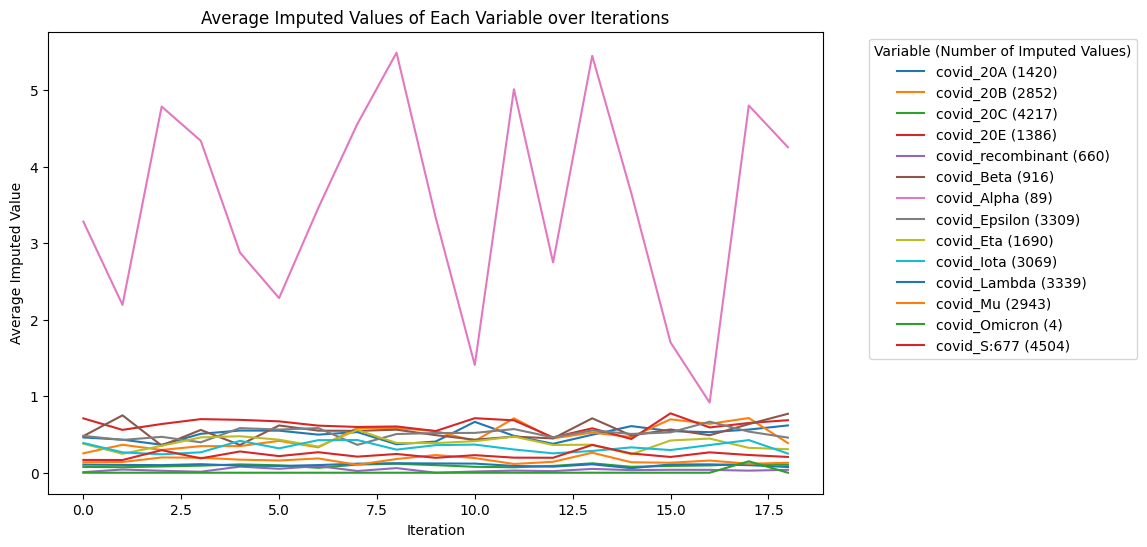

In [27]:
plt.figure(figsize=(10, 6))

for var_name, var_history in fcs.tracker.variables.items():
    avg_imputed_values = [np.mean(record.imputed_values) for record in var_history.history[1:]]  # skip initialization
    plt.plot(avg_imputed_values, label=f"{var_name} ({len(var_history.history[-1].imputed_values)})")

plt.xlabel('Iteration')
plt.ylabel('Average Imputed Value')
plt.title('Average Imputed Values of Each Variable over Iterations')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title="Variable (Number of Imputed Values)")
plt.show()